In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy import stats
from glob import glob
import torch.nn.functional as F
import torch

[W725 10:36:58.587697964 OperatorEntry.cpp:154] Warning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: aten::_validate_compressed_sparse_indices(bool is_crow, Tensor compressed_idx, Tensor plain_idx, int cdim, int dim, int nnz) -> ()
    registered at /pytorch/build/aten/src/ATen/RegisterSchema.cpp:6
  dispatch key: XPU
  previous kernel: registered at /pytorch/build/aten/src/ATen/RegisterCPU.cpp:30477
       new kernel: registered at /build/intel-pytorch-extension/build/Release/csrc/gpu/csrc/aten/generated/ATen/RegisterXPU.cpp:468 (function operator())


In [2]:
FILTER_SE_GENES = False # filter for only genes with SE events
FILTER_EVENT_GENES = False # filter for genes with SE or AR events
SINGLE_COUNT_GENES = True # average out predictions per gene_id
HURDLE_SEPARATION = False # separate 1 values from the rest of the psi predictions
NORMALISED_SCORES = False # show uncorrected scores when they were z-score normalised
BOTH_CELL_LINES = False # separate predictions for both cell lines

In [3]:
def get_predictions(date_folder):
    # find .csv file in the date folder
    csv_files = [f for f in glob(f"../trained_models/{date_folder}/*.csv") if not f.endswith('losses.csv')]
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {date_folder}")
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0])
    else:
        all_predictions = []
        for pred_file in csv_files:
            df = pd.read_csv(pred_file)
            #if 'Unnamed: 0' in df.columns:
            #    df = df.drop(columns=['Unnamed: 0'])
            all_predictions.append(df)
        return pd.concat(all_predictions, ignore_index=True)


In [4]:
predictions = get_predictions('2025-07-25/2025-07-25-09-23') # change here to the folder name you want to load 2025-07-08-09-56
predictions = predictions.rename(columns={'Unnamed: 0': 'gene_id', 'Pred': 'PredExpr', 'actual': 'ActualExpr'})
predictions

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000002016,1.116281,1.010724,GM12878,0.905371,1.000,1
1,ENSG00000002016,0.981380,1.010724,GM12878,0.813366,1.000,1
2,ENSG00000002016,1.144355,1.010724,GM12878,0.819760,0.208,1
3,ENSG00000002016,1.049704,1.010724,GM12878,0.959268,0.000,1
4,ENSG00000003056,1.595044,1.940716,GM12878,0.846293,1.000,1
...,...,...,...,...,...,...,...
3089,ENSG00000257390,0.375795,-0.552842,GM12878,0.993253,1.000,1
3090,ENSG00000257727,1.531781,2.163400,GM12878,0.968139,1.000,1
3091,ENSG00000257921,1.445339,-0.136677,GM12878,0.958603,1.000,1
3092,ENSG00000258311,1.116499,0.096910,GM12878,0.980226,1.000,1


In [5]:
if FILTER_SE_GENES:
    # filter predictions to the ones we have SE events for
    se_events = pd.read_csv('data/psi_response.csv')
    se_events = se_events[se_events['event_id'].str.contains(';SE:')]
    se_genes = set(se_events['gene_id'].unique())

    # filter down predictions to only those genes
    predictions_filtered = predictions[predictions['gene_id'].isin(se_genes)]
    len(predictions_filtered)

if FILTER_EVENT_GENES:
    se_events = pd.read_csv('data/psi_response.csv')
    se_events = set(se_events['gene_id'].unique())
    print(len(se_events), "genes with SE or AR events")

    predictions_filtered = predictions[predictions['gene_id'].isin(se_events)]
    print(len(predictions_filtered), "predictions for genes with SE or AR events")

In [6]:
if SINGLE_COUNT_GENES:
    # filter the predictions such that for one gene, we average out the predictions
    if FILTER_SE_GENES:
        predictions_filtered = predictions_filtered.groupby('gene_id').mean().reset_index()
    else:
        predictions_filtered = predictions.drop_duplicates(subset=['gene_id'], keep='first')

In [7]:
if not FILTER_SE_GENES and not SINGLE_COUNT_GENES and not FILTER_EVENT_GENES:
    predictions_filtered = predictions

In [8]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    r2_value = r2_score(predictions[actual_col], predictions[pred_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Pred (Pearson R: {pearsonR:.2f}, R²: {r2_value:.2f}, n={len(predictions)})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    
def plot_confusion_matrix(predictions, cell_line, pred_col, actual_col):
    confusion_matrix = pd.crosstab(predictions[pred_col], predictions[actual_col])
    
    plt.figure(figsize=(6,6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{cell_line} Confusion Matrix")
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()

K562


<Figure size 600x600 with 0 Axes>

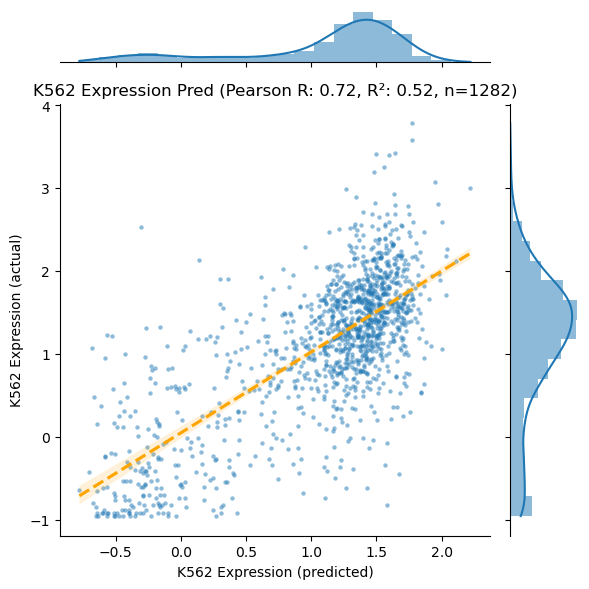

In [9]:
cell_line = 'K562' if not BOTH_CELL_LINES else 'K562/GM12878'
print(cell_line)
plot_predictions(predictions_filtered, cell_line=cell_line, pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

In [10]:
if BOTH_CELL_LINES:
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'K562'], cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'GM12878'], cell_line='GM12878', pred_col='PredExpr', actual_col='ActualExpr')

In [11]:
predictions_psi_filtered = None
binary_predictions = None
if HURDLE_SEPARATION:
    binary_predictions = predictions.copy()
    # convert all numbers that are not 1 to zero
    binary_predictions['PredPsi'] = np.where(binary_predictions['PredPsi'] == 1, "1", "0-0.99")
    binary_predictions['ActualPsi'] = np.where(binary_predictions['ActualPsi'] == 1, "1", "0-0.99")

    # predictions_psi_filtered = predictions[binary_predictions['ActualPsi'] != "1"].copy()
    predictions_psi_filtered = predictions[(predictions['PredPsi'] != 1) & (predictions['ActualPsi'] != 1)].copy()

In [12]:
predictions_psi_filtered

<Figure size 600x600 with 0 Axes>

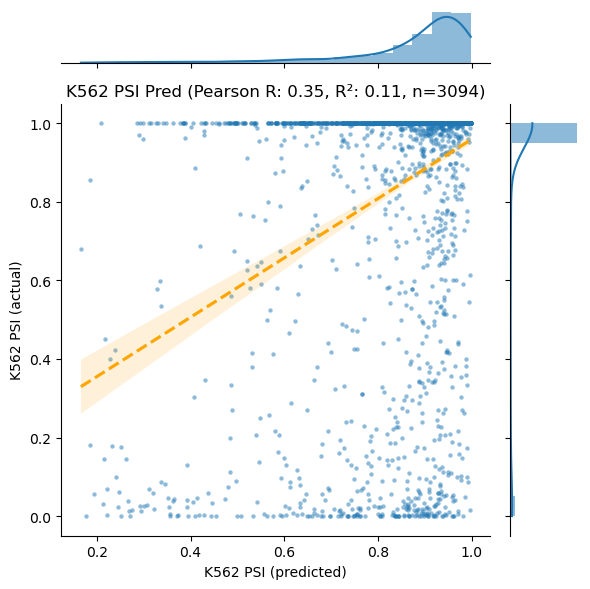

In [13]:
if binary_predictions is not None:
    plot_confusion_matrix(binary_predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
    plt.show()

if predictions_psi_filtered is None:
    predictions_psi_filtered = predictions[predictions['gene_id'].isin(se_genes)] if FILTER_SE_GENES else predictions.copy()
plot_predictions(predictions_psi_filtered, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()

In [50]:
if NORMALISED_SCORES:
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredPsi', actual_col='UncorrActualPsi')
    plt.show()
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredExpr', actual_col='UncorrActualExpr')
    plt.show()

## Check how similar predictions for the same genes are 

In [51]:
# filter for rows where gene_id appears more than once
predictions_multiple = predictions[predictions.duplicated(subset=['gene_id'], keep=False)]
predictions_multiple

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000002016,1.223812,1.010724,GM12878,0.823993,1.000000,1
1,ENSG00000002016,1.185180,1.010724,GM12878,0.868482,1.000000,1
2,ENSG00000002016,1.359310,1.010724,GM12878,0.617100,0.208000,1
3,ENSG00000002016,1.235182,1.010724,GM12878,0.751224,0.000000,1
4,ENSG00000003056,0.986043,1.940716,GM12878,0.837048,1.000000,1
...,...,...,...,...,...,...,...
2797,ENSG00000256223,1.356013,0.584331,GM12878,0.860000,1.000000,1
2798,ENSG00000256223,1.377838,0.584331,GM12878,0.839990,1.000000,1
2799,ENSG00000256223,1.443066,0.584331,GM12878,0.856726,1.000000,1
2800,ENSG00000257218,2.169866,1.438384,GM12878,0.873049,1.000000,1


In [52]:
predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()
predictions_multiple

/tmp/ipykernel_2071038/27208789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()


,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx,index
0,ENSG00000002016,1.223812,1.010724,GM12878,0.823993,1.000000,1,0
1,ENSG00000002016,1.185180,1.010724,GM12878,0.868482,1.000000,1,1
2,ENSG00000002016,1.359310,1.010724,GM12878,0.617100,0.208000,1,2
3,ENSG00000002016,1.235182,1.010724,GM12878,0.751224,0.000000,1,3
4,ENSG00000003056,0.986043,1.940716,GM12878,0.837048,1.000000,1,0
...,...,...,...,...,...,...,...,...
2797,ENSG00000256223,1.356013,0.584331,GM12878,0.860000,1.000000,1,1
2798,ENSG00000256223,1.377838,0.584331,GM12878,0.839990,1.000000,1,2
2799,ENSG00000256223,1.443066,0.584331,GM12878,0.856726,1.000000,1,3
2800,ENSG00000257218,2.169866,1.438384,GM12878,0.873049,1.000000,1,0


In [53]:
summary = (
    predictions_multiple
    .groupby('gene_id')['PredExpr']
    .agg(['min', 'max', 'mean'])
    .assign(range=lambda x: x['max'] - x['min'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
summary

,gene_id,min,max,mean,range
0,ENSG00000092841,2.382315,2.485697,2.451150,0.103382
1,ENSG00000198270,2.352769,2.446010,2.406732,0.093241
2,ENSG00000205323,2.383414,2.386181,2.384798,0.002767
3,ENSG00000115207,2.343623,2.343623,2.343623,0.000000
4,ENSG00000037897,2.307962,2.362904,2.337837,0.054942
...,...,...,...,...,...
734,ENSG00000111328,0.499597,0.499597,0.499597,0.000000
735,ENSG00000127329,0.463169,0.512748,0.488574,0.049579
736,ENSG00000119772,0.404024,0.483454,0.451557,0.079430
737,ENSG00000138031,0.444040,0.451432,0.448855,0.007392


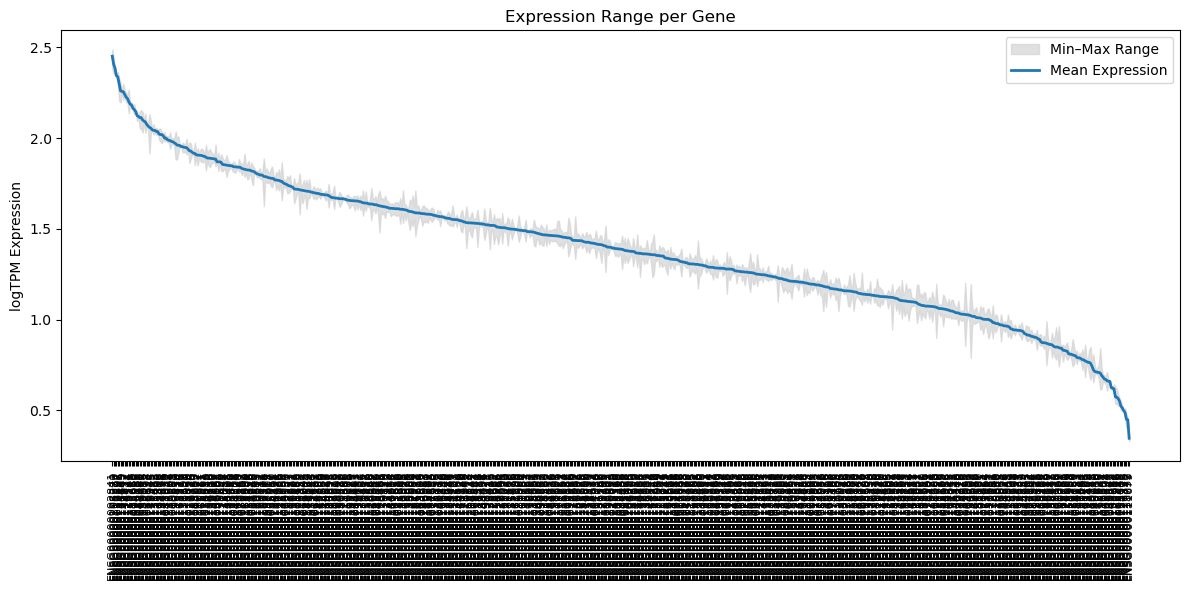

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(summary))

# Shaded area for min-max range
ax.fill_between(x, summary['min'], summary['max'], color='lightgray', alpha=0.7, label='Min–Max Range')

# Line for the mean
ax.plot(x, summary['mean'], linewidth=2, label='Mean Expression')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(summary['gene_id'], rotation=90, fontsize=8)
ax.set_ylabel("logTPM Expression")
ax.set_title("Expression Range per Gene")
ax.legend()
plt.tight_layout()
plt.show()